# <center> Machine Learning in Computational Biology - Term Project </center>

## <center> Task A </center>
### <center> Data Acquisition, EDA & Preprocessing </center>
---
#### **Instructor:** Prof. Elias Manolakos  
#### **MSc:** Data Science & Information Technologies 2025-2026 
#### **Department:** Informatics & Telecommunications of the National & Kapodistrian University of Athens (NKUA)
---
**Paper of Choice:** Full citation: Pinhasi, A., Yizhak, K. Uncovering gene and cellular signatures of immune checkpoint response via machine learning and single-cell RNA-seq. npj Precis. Onc. 9, 95 (2025). https://doi.org/10.1038/s41698-025-00883-z  

**Link:** https://www.nature.com/articles/s41698-025-00883-z 

**Dataset Availability:** https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE120575

---
## **Dataset & Task A Description:**
→ Melanoma single cell Analysis of Homo sapiens (genome build	GRCh37 (hg19))
  - 32 metastatic melanoma patients 
  - Pre = baseline (pre-treatment), Post = on treatment (naming of patients Pre_Px or Post_Px, where x=the id of the patient)
  - 48 tumor biopsies (scRNA-seq performance) [2]

   **→ More specifically:** 
   
   > a) Treatment of biopsies: 35 anti-PD1; 11 anti-CTLA4+PD1; and 2 anti-CTLA4 samples [2].

   > b) Including 11 patients with longitudinal biopsies taken at baseline (e.g., Pre) and during treatment (e.g. Post); 1 patient with 2 biopsies taken at one time point; and 20 patients with one sample each, taken at baseline (Pre) or during treatment (Post) [2]. 

   > c) Regarding clinical response, it was originally assessed using RECIST criteria, with 1) complete response and partial response = Responders labeling, while 2) stable disease and progressive disease  = Non-responders labeling. Therefore, the metadata for supervised modeling have a binary response label: Responder vs. Non-responder [2].

   > d) Expression levels were quantified as Transcripts Per Million (TPM) [2].
---

### Final obtained data: 
After Quality control (QC) measures [2]:

1) cells with a zero expression of both CD45

2) cells expressing fewer than 1000 genes 

3) cells with an average expression of housekeeping genes, log2(TPM+1) < 2.5.

---

### Final TXT Files of use: 
1. GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO: tab-delimited text file containing log2(TPM+1) values for 55,737 transcripts (rows) and 16,291 cells (columns) [2]

2. GSE120575_patient_ID_single_cells: Sample name, title, source name organism, patient ID (Pre=baseline; Post= on treatment), response, therapy. 																
---

**Example of sample naming Explanation:** 
The sample naming consists of `three primary identifiers` followed by `at least 3 additional descriptors` that indicate sample-specific processing steps or experimental modifications.

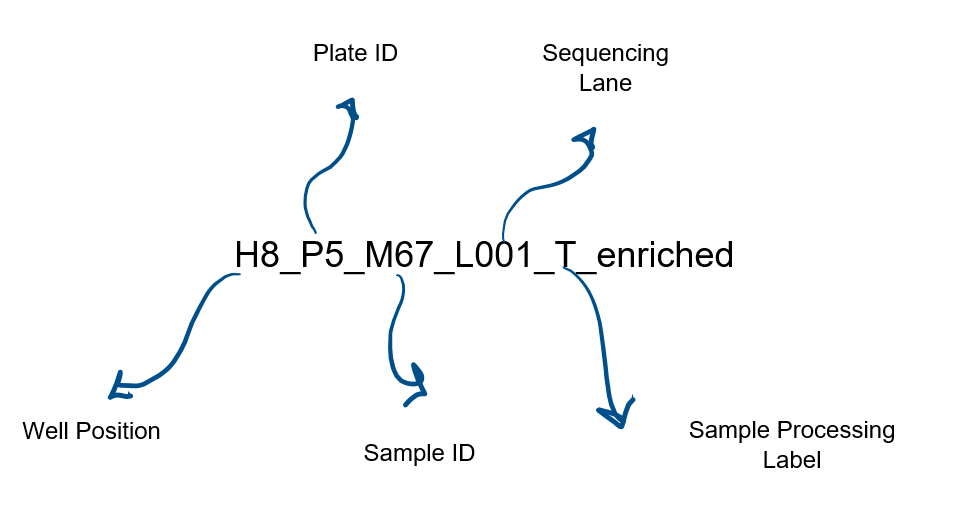


> **Aim of Study:** Ιdentification of gene and cellular signatures associated with responder vs. non-responder status in melanoma patients treated with immune checkpoint therapy.

---


# Libraries & Paths

In [1]:
#Libraries
import random, os
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import scipy.sparse as sp # Library used in order to load the expression matrix in chunks 
from scipy.sparse import save_npz # Saving the chunks into npz file format
import re # work with Regular Expressions when using re.search() [7]

#import wandb
#wandb.login() # Use of wandb (Weights & Biases) to track model configurations, performance metrics, plots, and experiment comparisons in a reproducible way.

# Seed of use for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

# Setting the path of input & output data 
data_dir   = Path('../data')   
output_dir = Path('../outputs')
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir = Path("../figures")
figures_dir.mkdir(parents=True, exist_ok=True)


tmp_file  = data_dir / "GSE120575_Sade_Feldman_melanoma_single_cells_TPM_GEO.txt"
metadata_file   = data_dir / "GSE120575_patient_ID_single_cells.txt"   # ~4 GB


# Plot setting using seaborn 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 11

print("Finished")

Finished


## Loading & Inspecting Patient Metadata

In [2]:
# Parsing GEO metadata since first 19 lines are not needed for data extraction 
metadata = pd.read_csv(metadata_file, sep="\t", skiprows=19, encoding="latin-1")

# Keeping a copy only of the important cols that will be used later for merging with the expression matrix and supervised model training
metadata = metadata[["Sample name", "title","characteristics: patinet ID (Pre=baseline; Post= on treatment)","characteristics: response","characteristics: therapy"]].copy()
# Renaming for better use and clarity
metadata.columns = ["sample_name", "cell_id", "patient_timepoint", "response", "therapy"]

# Removing any duplicated header or header in general row accidentally included as a data row in the GEO metadata file (Since the first total cells where = 16,329 ≠ 16291 expected from data description)
metadata = metadata[metadata["response"].isin(["Responder", "Non-responder"])].reset_index(drop=True)

# Deriving the columns of Analysis
metadata["timepoint"]  = metadata["patient_timepoint"].str.extract(r"^(Pre|Post)")
metadata["patient_id"] = metadata["patient_timepoint"].str.extract(r"(P\d+)")

# Setting 1=Response, 0=Non-Response (binary label)
metadata["label"] = (metadata["response"] == "Responder").astype(int)  
 
############################################################################
print(f"Total cells in metadata : {len(metadata):,}")
print(f"Unique patients: {metadata['patient_id'].nunique()}")
metadata.head(5)

Total cells in metadata : 16,291
Unique patients: 32


,sample_name,cell_id,patient_timepoint,response,therapy,timepoint,patient_id,label
0,Sample 1,A10_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,1
1,Sample 2,A11_P1_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,1
2,Sample 3,A11_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,1
3,Sample 4,A11_P4_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,1
4,Sample 5,A12_P3_M11,Pre_P1,Responder,anti-CTLA4,Pre,P1,1


### Additional checking

In [3]:
print(f"Missing values per column: \n{metadata.isnull().sum()}")
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print("\nDuplicate cell_id rows")
dup = metadata.duplicated(subset="cell_id")
print(f" Duplicates: {dup.sum()}")
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print(f"\nResponse distribution: \n {metadata["response"].value_counts()}")
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print(f"\nTimepoint distribution:\n {metadata["timepoint"].value_counts()}")
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print(f"\nTherapy distribution:\n {metadata["therapy"].value_counts()}")
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print(f"\nTreatment x Response cross-tab: \n {pd.crosstab(metadata["therapy"], metadata["response"])} ")

Missing values per column: 
sample_name          0
cell_id              0
patient_timepoint    0
response             0
therapy              0
timepoint            0
patient_id           0
label                0
dtype: int64

++++++++++++++++++++++++++++++++++++++++++++++++

Duplicate cell_id rows
 Duplicates: 0

++++++++++++++++++++++++++++++++++++++++++++++++

Response distribution: 
 response
Non-responder    10727
Responder         5564
Name: count, dtype: int64

++++++++++++++++++++++++++++++++++++++++++++++++

Timepoint distribution:
 timepoint
Post    10363
Pre      5928
Name: count, dtype: int64

++++++++++++++++++++++++++++++++++++++++++++++++

Therapy distribution:
 therapy
anti-PD1          11653
anti-CTLA4+PD1     4121
anti-CTLA4          517
Name: count, dtype: int64

++++++++++++++++++++++++++++++++++++++++++++++++

Treatment x Response cross-tab: 
 response        Non-responder  Responder
therapy                                 
anti-CTLA4                288        229
a

---
## Loading the Expression Matrix (TPM)



In [4]:
# First Step: Inspecting the form of the data of the specific file since is a large one. 
# Printing the first 10 lines.
with open(tmp_file, "r", encoding="latin1") as f:
    for i in range(10):
        # Printing the number of fields in order to inspect the empty cell created due to the Transcripts column presence 
        line = f.readline().rstrip("\n")
        print(i + 1, "fields:", len(line.split("\t")))
        print(line[:300])
        print("-" * 200)
# Having a total of 55,737 transcripts (rows) and 16,291 cells (columns) as said from the NCBI + 1 the gene name. 

1 fields: 16292
	A10_P3_M11	A11_P1_M11	A11_P3_M11	A11_P4_M11	A12_P3_M11	A12_P6_M11	A2_P1_M11	A2_P4_M11	A3_P1_M11	A3_P3_M11	A4_P3_M11	A4_P4_M11	A4_P6_M11	A5_P4_M11	A5_P5_M11	A6_P1_M11	A6_P4_M11	A6_P6_M11	A7_P2_M11	A7_P6_M11	A8_P1_M11	A8_P6_M11	A9_P1_M11	A9_P4_M11	B10_P1_M11	B10_P3_M11	B10_P4_M11	B10_P6_M11	B11_P6_M1
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
2 fields: 16292
	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P1	Pre_P
---------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [5]:
#Checking the reason of differents in the total cells that each row has.
with open(tmp_file, "r", encoding="latin1") as f:
    line1 = f.readline().rstrip("\n").split("\t")
    line2 = f.readline().rstrip("\n").split("\t")
    line3 = f.readline().rstrip("\n").split("\t")
print("line1 first 5:", line1[:3])
print("line1 last 5:", line1[-3:])
print("line2 first 5:", line2[:3])
print("line2 last 5:", line2[-3:])
print("line3 first 5:", line3[:3])
print("line3 last 5:", line3[-3:])

# Observed empty trailing column in the start of the first two lines and in the end of the line 3.
# Explains the differences in the total cells per row with and without the gene name. 

# Checking if all the gene rows end with a trailing empty cell
checked = 0
empty_cell = 0
with open(tmp_file, "r", encoding="latin1") as f:
    next(f)
    next(f)
    for line in f:
        fields = line.rstrip("\n").split("\t")
        checked += 1
        if fields[-1] == "":
            empty_cell += 1
print("\n++++++++++++++++++++++++++++++++++++++++++++++++")
print("Gene rows checked:", checked)
print("Rows with empty trailing space:", empty_cell)

line1 first 5: ['', 'A10_P3_M11', 'A11_P1_M11']
line1 last 5: ['H7_P5_M67_L001_T_enriched', 'H8_P5_M67_L001_T_enriched', 'H9_P5_M67_L001_T_enriched']
line2 first 5: ['', 'Pre_P1', 'Pre_P1']
line2 last 5: ['Post_P6_T_enriched', 'Post_P6_T_enriched', 'Post_P6_T_enriched']
line3 first 5: ['TSPAN6', '0.00', '0.00']
line3 last 5: ['0.00', '0.00', '']

++++++++++++++++++++++++++++++++++++++++++++++++
Gene rows checked: 55737
Rows with empty trailing space: 55737


In [6]:
# Second Step: Reading the tmp file into chunks of 500 genes due to its large size. 
# Reading the first two lines manually
with open(tmp_file, "r", encoding="latin-1") as f:
    cell_names = f.readline().rstrip("\n").split("\t")[1:]
    timepoint_row = f.readline().rstrip("\n").split("\t")[1:]
    
print("Number of samples:", len(cell_names))
print("Number of Patients x Timepoint of treatment labels:", len(timepoint_row))
print(cell_names[:5])
print(timepoint_row[:5])

# Defining the column names for expression rows which are gene_name + expression values for all cells
columns = ["gene"] + cell_names

# Reading the expression matrix in chunks of 500
chunks = []
gene_names = []
reader = pd.read_csv(tmp_file,sep="\t",skiprows=2, header=None, names=columns,usecols=range(len(columns)),encoding="latin-1",engine="python",chunksize=500) # also dropping the extra empty cell in the back of genes' rows

for i, chunk in enumerate(reader):
    genes = chunk["gene"].astype(str).tolist()
    expres = chunk.drop(columns="gene")
    expres = expres.apply(pd.to_numeric, errors="coerce").fillna(0)
    gene_names.extend(genes)
    # Τransposing the matrix to cells x genes
    X_chunk = sp.csr_matrix(expres.values.T.astype(np.float32))
    chunks.append(X_chunk)
    
    print(f"Processed chunk {i+1}, genes so far: {len(gene_names)}")

Number of samples: 16291
Number of Patients x Timepoint of treatment labels: 16291
['A10_P3_M11', 'A11_P1_M11', 'A11_P3_M11', 'A11_P4_M11', 'A12_P3_M11']
['Pre_P1', 'Pre_P1', 'Pre_P1', 'Pre_P1', 'Pre_P1']
Processed chunk 1, genes so far: 500
Processed chunk 2, genes so far: 1000
Processed chunk 3, genes so far: 1500
Processed chunk 4, genes so far: 2000
Processed chunk 5, genes so far: 2500
Processed chunk 6, genes so far: 3000
Processed chunk 7, genes so far: 3500
Processed chunk 8, genes so far: 4000
Processed chunk 9, genes so far: 4500
Processed chunk 10, genes so far: 5000
Processed chunk 11, genes so far: 5500
Processed chunk 12, genes so far: 6000
Processed chunk 13, genes so far: 6500
Processed chunk 14, genes so far: 7000
Processed chunk 15, genes so far: 7500
Processed chunk 16, genes so far: 8000
Processed chunk 17, genes so far: 8500
Processed chunk 18, genes so far: 9000
Processed chunk 19, genes so far: 9500
Processed chunk 20, genes so far: 10000
Processed chunk 21, gene

In [7]:
# Third step: Combining the output chunks and saving them in one file, also making new separate files regarding the cell_names, timepoints of response and the gene_names
# since we previously created only a numeric expression matrix.

# Combining the chunks of cells x genes
X = sp.hstack(chunks, format="csr") #[3]

# Saving the files into the outputs directory
save_npz(output_dir / "X_cells_by_genes.npz", X) #[4]
pd.Series(cell_names, name="cell_id").to_csv(output_dir / "cell_names.csv", index=False)
pd.Series(timepoint_row, name="timepoint").to_csv(output_dir / "timepoints_from_tpm_patients.csv", index=False)
pd.Series(gene_names, name="gene").to_csv(output_dir / "gene_names.csv", index=False)


print("Final expression matrix shape:", X.shape)
print("Saved")

Final expression matrix shape: (16291, 55737)
Saved


---
## Merging the Metadata 

The clinical metadata and the scRNA-seq expression matrix were aligned and merged using the unique `cell identifiers` shared between both datasets, with the expression matrix being converted into an AnnData object, and matched with the metadata table to ensure that each cell was associated with its corresponding clinical information (response, therapy, patient ID and timepoint), following the strategy described in the authors' github repository [5], [6].


In [8]:
# Reloading the files in order to change them to anndata object
X = sp.load_npz(output_dir / "X_cells_by_genes.npz")
cell_names = pd.read_csv(output_dir / "cell_names.csv")["cell_id"].astype(str).tolist() # unique
gene_names = pd.read_csv(output_dir / "gene_names.csv")["gene"].astype(str).tolist()
tpm_pat_labels = (pd.read_csv(output_dir / "timepoints_from_tpm_patients.csv")["timepoint"].astype(str).tolist()) # used as annotation file

# Rechecking shape
print("-------Size--------")
print("Expression matrix:", X.shape) 
print("Samples:", len(cell_names)) 
print("Genes:", len(gene_names)) 
print("Patient_timepoint:", len(tpm_pat_labels))

-------Size--------
Expression matrix: (16291, 55737)
Samples: 16291
Genes: 55737
Patient_timepoint: 16291


In [9]:
# Creating the AnnData object 
# First focus: Expression Matrix
adata = sc.AnnData( X=X, obs=pd.DataFrame( index=pd.Index(cell_names, name="cell_id") ), var=pd.DataFrame( index=pd.Index(gene_names, name="gene") ) ) 
# Checking for duplicate gene names for the anndata addition
print("Checking for duplicate gene names:", adata.var_names.duplicated().sum())
print("AnnData shape:", adata.shape)

Checking for duplicate gene names: 0
AnnData shape: (16291, 55737)


In [10]:
#Clean and check cell id's before running the matching for any possible inconsistencies especially space characters
def clean_cell_id(x):
    return str(x).strip()

adata.obs["cell_id_original"] = adata.obs_names.astype(str)
adata.obs["cell_id_clean"] = adata.obs["cell_id_original"].map(clean_cell_id)

In [11]:
# Second focus: Metadata file
# Creating a copy of the metadata, ensuring no mistake or original data alteration, and standarizing cell ids for matching
meta = metadata.copy()
meta["cell_id_clean"] = meta["cell_id"].map(clean_cell_id)

# Checking overlap expression matrix-metadata
adata_ids = pd.Index(adata.obs["cell_id_clean"])
meta_ids = pd.Index(meta["cell_id_clean"])

# Identifying the common between them
common_cells = adata_ids.intersection(meta_ids)


print(f"Cells in expression matrix : {adata.n_obs:,}")
print(f"Cells in metadata : {len(meta):,}")
if len(common_cells) == adata.n_obs:
    print("All matched")
else: 
    print("Re-do")

Cells in expression matrix : 16,291
Cells in metadata : 16,291
All matched


In [12]:
# Aligning the metadata to AnnData 
meta_indexed = meta.set_index("cell_id_clean")

# Keeping the expression cells present to both metadata and expression matrix
keep_mask = adata.obs["cell_id_clean"].isin(meta_indexed.index)
adata = adata[keep_mask].copy()

# Attaching the metadata in the exact same order as adata.obs
adata.obs = adata.obs.join(meta_indexed, on="cell_id_clean", how="left", rsuffix="_meta")

print(f"AnnData after merge: {adata.shape}")
print(f"Missing responses: {adata.obs["response"].isna().sum()}\n\n"f"{adata.obs["response"].value_counts(dropna=False)}") # remaining the shame as previously checked
print("obs columns:", list(adata.obs.columns))

AnnData after merge: (16291, 55737)
Missing responses: 0

response
Non-responder    10727
Responder         5564
Name: count, dtype: int64
obs columns: ['cell_id_original', 'cell_id_clean', 'sample_name', 'cell_id', 'patient_timepoint', 'response', 'therapy', 'timepoint', 'patient_id', 'label']


In [13]:
# Dropping columns that are not useful since we have kept their input already once differently in the AnnData; e.g., patient and timepoint are also split.
# for easier use from the model.
# 1=R, 0=NR binary response label
# Naming based on the author's GitHub repository 
adata.obs.drop(columns=["cell_id_original", "cell_id_clean","patient_timepoint","response","cell_id"],inplace=True,errors="ignore")
adata.obs.rename(columns={"label": "response"},inplace=True)
adata.obs = adata.obs.rename(columns={"sample_name": "sample"})

In [14]:
######################################################################
# Preview of the final integrated dataset
######################################################################
print("\nFirst metadata rows:") 
display(adata.obs.head())
print(f"\nFirst 10 genes:{adata.var_names[:10].tolist()}")


# Creating a dataframe to preview the expression matrix and check if the results are correct after the transposition
expression_preview = pd.DataFrame(
    adata[:5, :10].X.toarray()
    if sp.issparse(adata.X)
    else adata[:5, :10].X,
    index=adata.obs_names[:5],
    columns=adata.var_names[:10]
)
display(expression_preview)


First metadata rows:


,sample,therapy,timepoint,patient_id,response
cell_id,,,,,
A10_P3_M11,Sample 1,anti-CTLA4,Pre,P1,1
A11_P1_M11,Sample 2,anti-CTLA4,Pre,P1,1
A11_P3_M11,Sample 3,anti-CTLA4,Pre,P1,1
A11_P4_M11,Sample 4,anti-CTLA4,Pre,P1,1
A12_P3_M11,Sample 5,anti-CTLA4,Pre,P1,1



First 10 genes:['TSPAN6', 'TNMD', 'DPM1', 'SCYL3', 'C1orf112', 'FGR', 'CFH', 'FUCA2', 'GCLC', 'NFYA']


gene,TSPAN6,TNMD,DPM1,SCYL3,C1orf112,FGR,CFH,FUCA2,GCLC,NFYA
cell_id,,,,,,,,,,
A10_P3_M11,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A11_P1_M11,0.0,0.0,9.24,0.0,0.0,0.0,0.0,0.0,1.01,0.0
A11_P3_M11,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A11_P4_M11,0.0,0.0,7.99,0.0,0.0,0.0,0.0,0.0,0.00,0.0
A12_P3_M11,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.0


In [15]:
print("Final obs columns:")
print(adata.obs.columns.tolist())

# Code cell in order to recheck the correspondence of the results with the original data
print("\nCell-level therapy x response:")
print(pd.crosstab(adata.obs["therapy"], adata.obs["response"]))

print("\nCell-level Patient's timepoint x response:")
print(pd.crosstab(adata.obs["timepoint"], adata.obs["response"]))

if "patient_id" in adata.obs.columns:
    patient_meta = adata.obs.drop_duplicates(subset="patient_id")
    print("\nPatient's therapy x response:")
    print(pd.crosstab(patient_meta["therapy"], patient_meta["response"]))
# These checks match and should match the initial metadata summaries.

Final obs columns:
['sample', 'therapy', 'timepoint', 'patient_id', 'response']

Cell-level therapy x response:
response           0     1
therapy                   
anti-CTLA4       288   229
anti-CTLA4+PD1  1501  2620
anti-PD1        8938  2715

Cell-level Patient's timepoint x response:
response      0     1
timepoint            
Post       7524  2839
Pre        3203  2725

Patient's therapy x response:
response         0  1
therapy              
anti-CTLA4       1  1
anti-CTLA4+PD1   2  4
anti-PD1        17  7


In [16]:
# Saving the final integrated anndata object
adata.write_h5ad( output_dir / "GSE120575_new_anndata.h5ad" ) 
print( "Saved" )

Saved


In [17]:
# Final check of the results - Missing values 
# Shape of data as expected; no need to check for duplicates


# Searching for missing values in the expression matrix data 
print("\nChecking the expression matrix:")
if sp.issparse(adata.X):
    expression_values = adata.X.data
    missing_count = np.isnan(expression_values).sum()
    inf_count = np.isinf(expression_values).sum()
    # Calculating zeros, which are stored implicitly in a sparse matrix, and expression sparsity
    total_values = adata.n_obs * adata.n_vars
    zero_count = total_values - adata.X.count_nonzero()
else:
 print("Recheck")
 

print("Missing expression values:", missing_count)
print("Infinite expression values:", inf_count)
print("Zero expression values:", zero_count)
print("Expression sparsity:",f"{100 * zero_count / total_values:.2f}% zeros")
# Also, final check of the genes 
print("\n")
gene_ids = pd.Index(adata.var_names.astype(str))
print("Missing gene names:", adata.var_names.isna().sum())
print("Empty gene names:", pd.Series(gene_ids).str.strip().eq("").sum())


print("\n")
# Checking the rest columns that came up from the metadata
required_columns = ["response","patient_id","timepoint","therapy"]
for column in required_columns:
    if column in adata.obs.columns:
        print(
            f"{column}:"
            f"{adata.obs[column].isna().sum()} missing values")
        


Checking the expression matrix:
Missing expression values: 0
Infinite expression values: 0
Zero expression values: 868773246
Expression sparsity: 95.68% zeros


Missing gene names: 0
Empty gene names: 0


response:0 missing values
patient_id:0 missing values
timepoint:0 missing values
therapy:0 missing values


---
# Quality Control


According to the samples and the initial data processing performed by the original authors, a `first round of quality control measures` was applied, as mentioned in the introduction of this notebook. Specifically, the following QC criteria were used [2]: 1) cells with zero expression of CD45 were excluded; 2) cells expressing fewer than 1000 genes were excluded; and 3) cells with an average housekeeping gene expression of log2(TPM+1) < 2.5 were also excluded.

Following this initial quality control, the authors of the PRECISE study applied additional gene-level filtering to the dataset. As reproduced in the following code cells, `non-coding genes`, mitochondrial genes, and ribosomal-related genes (genes beginning with `MT-`, `RPS`, `RPL`, `MRP`, and `MTRNR)` were removed, while also, only `genes expressed in at least 3% of cells were retained`, resulting in a final set of 10,082 genes as reported in the study.

In [2]:
# Reloading the integrated anndata
adata = sc.read_h5ad(output_dir / "GSE120575_new_anndata.h5ad")
print("Loading the AnnData:", adata.shape)

Loading the AnnData: (16291, 55737)


## Detecting the Mitochodrial and Ribosomal genes

In [3]:
# First step of Quality Control analysis is the detection of the genes, that we need to exclude
gene_names_new = adata.var_names.astype(str)
# Detecting the MT- starting mitochondrial genes
adata.var["mt"] = gene_names_new.str.startswith("MT-") 
print(f"\nMitochondrial genes detected, equal to: {adata.var["mt"].sum()}")

# Detecting the ribosomal genes
adata.var["ribosomal_1"] = gene_names_new.str.startswith(("RPS"))
adata.var["ribosomal_2"] = gene_names_new.str.startswith(("RPL"))
print(f"\nRibosomal genes detected, equal to: RPS={adata.var["ribosomal_1"].sum()}\t RPL={adata.var["ribosomal_2"].sum()}")

# Detecting the MT and ribosomal related genes
adata.var["mit_rib_related_1"] = gene_names_new.str.startswith(("MRP"))
adata.var["mit_rRNA_related_2"] = gene_names_new.str.startswith(("MTRNR"))
print(f"\nMitochondrial-ribosomal related genes detected, equal to: MRP={adata.var["mit_rib_related_1"].sum()}\
\tMTRNR={adata.var["mit_rRNA_related_2"].sum()}")


Mitochondrial genes detected, equal to: 37

Ribosomal genes detected, equal to: RPS=344	 RPL=583

Mitochondrial-ribosomal related genes detected, equal to: MRP=146	MTRNR=13


## QC before filtering genes

In [4]:
# Computing per-cell QC metrics before removing mitochondrial genes
sc.pp.calculate_qc_metrics(adata,qc_vars=["mt"],percent_top=None,log1p=False,inplace=True)
qc_cols = ["n_genes_by_counts", "pct_counts_mt"]
print("QC metrics before filtering:")
print(adata.obs[qc_cols].describe().round(2))

QC metrics before filtering:
       n_genes_by_counts  pct_counts_mt
count           16291.00       16291.00
mean             2408.58           1.08
std               946.53           0.32
min              1093.00           0.02
25%              1795.00           0.86
50%              2151.00           1.06
75%              2708.50           1.27
max              9315.00           4.02


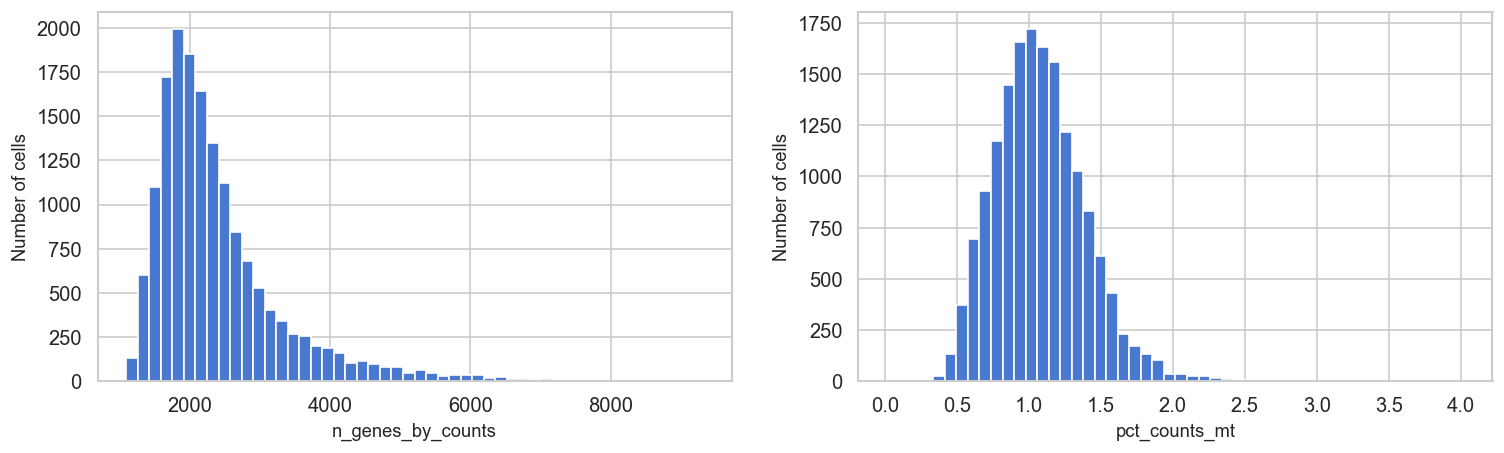

In [5]:
# Also plotting the Distribution of genes per total number of cells. 
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for ax, col in zip(axes, qc_cols):
    ax.hist(adata.obs[col], bins=50)
    ax.set_xlabel(col)
    ax.set_ylabel("Number of cells")
    
plt.savefig(figures_dir / "qc_distributions_before_filtering.png")
plt.show()

**Comment**: The distribution of detected genes per cell (n_genes_by_counts) shows that most cells express between approximately 1,500 and 3,000 genes, while only a small number of cells exhibit unusually high gene counts. Also, the percentage of mitochondrial gene expression remains very low across the dataset, according to the QC metrics too (median ~ 1.06%, maximum ~ 4.02%), suggesting that a substantial population of low-quality or damaged cells is absent.   

Therefore, the QC metrics indicate that the `dataset is generally of high quality`, which is consistent with the original preprocessing performed by the authors, guiding us to perform only the analysis proceeded with the `gene-level filtering strategy described by the PRECISE study`.

In [6]:
# Observe the data
h19_file = Path("../data/gencode.v19.annotation.gtf_withproteinids")  
with open(h19_file, "r") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i == 10:
            break

##description: evidence-based annotation of the human genome (GRCh37), version 19 (Ensembl 74)
##provider: GENCODE
##contact: gencode@sanger.ac.uk
##format: gtf
##date: 2013-12-05
chr1	HAVANA	gene	11869	14412	.	+	.	gene_id "ENSG00000223972.4"; transcript_id "ENSG00000223972.4"; gene_type "pseudogene"; gene_status "KNOWN"; gene_name "DDX11L1"; transcript_type "pseudogene"; transcript_status "KNOWN"; transcript_name "DDX11L1"; level 2; havana_gene "OTTHUMG00000000961.2";
chr1	HAVANA	transcript	11869	14409	.	+	.	gene_id "ENSG00000223972.4"; transcript_id "ENST00000456328.2"; gene_type "pseudogene"; gene_status "KNOWN"; gene_name "DDX11L1"; transcript_type "processed_transcript"; transcript_status "KNOWN"; transcript_name "DDX11L1-002"; level 2; tag "basic"; havana_gene "OTTHUMG00000000961.2"; havana_transcript "OTTHUMT00000362751.1";
chr1	HAVANA	exon	11869	12227	.	+	.	gene_id "ENSG00000223972.4"; transcript_id "ENST00000456328.2"; gene_type "pseudogene"; gene_status "KNOWN"; gene_name "DD

## GENCODE hg19 annotation addition 

In [8]:
# Loading and parsing the GENCODE v19 annotations in order to identify protein-coding and non-coding genes to use in the later exclusion genes step.
records = []
with open(h19_file, "r") as f:
    for line in f:
        if line.startswith("#"): # Parse first lines
            continue
        fields = line.strip().split("\t") # Split - Fields insert data
        if len(fields) < 9 or fields[2] != "gene":
            continue
        attributes = fields[8]
        gene_name_match = re.search(r'gene_name "([^"]+)"', attributes) # Searching names 
        gene_type_match = re.search(r'gene_type "([^"]+)"', attributes) # and categories

        if gene_name_match and gene_type_match:
            records.append({"gene_name": gene_name_match.group(1), "gene_type": gene_type_match.group(1)})

gencode = pd.DataFrame(records).drop_duplicates()
print("GENCODE genes parsed:", gencode.shape[0])
print(gencode["gene_type"].value_counts().head(10))

GENCODE genes parsed: 55808
gene_type
protein_coding          20242
pseudogene              13919
lincRNA                  7105
antisense                5272
miRNA                    3046
snRNA                    1903
misc_RNA                 1214
sense_intronic            741
rRNA                      521
processed_transcript      514
Name: count, dtype: int64


In [9]:
# Extracting protein-coding genes from GENCODE annotation
protein_coding_genes = set(gencode.loc[gencode["gene_type"] == "protein_coding","gene_name"].astype(str))

# Matching annData gene names to the GENCODE protein-coding gene list
# Non protein-coding genes --> non_coding or unmatched
adata.var["protein_coding"] = adata.var_names.astype(str).isin(protein_coding_genes)
adata.var["non_coding_or_unmatched"] = ~adata.var["protein_coding"]

# Summary table of gene categories and the total count from both datasets
gene_category_summary = pd.DataFrame({
    "category": ["MT-","RPS","RPL","MRP","MTRNR","Protein-coding genes","Non-coding or unmatched genes"],
    "count": [adata.var["mt"].sum(), adata.var["ribosomal_1"].sum(), adata.var["ribosomal_2"].sum(),
        adata.var["mit_rib_related_1"].sum(), adata.var["mit_rRNA_related_2"].sum(), adata.var["protein_coding"].sum(),
        adata.var["non_coding_or_unmatched"].sum()]
})
display(gene_category_summary)

,category,count
0,MT-,37
1,RPS,344
2,RPL,583
3,MRP,146
4,MTRNR,13
5,Protein-coding genes,20214
6,Non-coding or unmatched genes,35523


In [10]:
# Defining the genes that need to be removed
rm_genes = (adata.var["mt"] | adata.var["ribosomal_1"] | adata.var["ribosomal_2"] | adata.var["mit_rib_related_1"] \
    | adata.var["mit_rRNA_related_2"] | adata.var["non_coding_or_unmatched"] )

print("Genes before filtering:", adata.n_vars)
print("Genes to remove:", rm_genes.sum())

Genes before filtering: 55737
Genes to remove: 35729


In [11]:
# Making a copy of anndata and proceeding to the removal of genes 
adata = adata[:, ~rm_genes].copy()
print(f"After removing genes, we are having: {adata.n_vars:,} genes")

# Keeping only genes expressed in >= 3% of cells 
min_cells = int(np.ceil(0.03 * adata.n_obs))
sc.pp.filter_genes(adata,min_cells=min_cells)
print(f"\nMinimum cells required per gene: {min_cells:,}")
print(f"Genes after 3% of cells filtering: {adata.n_vars:,}")

After removing genes, we are having: 20,008 genes

Minimum cells required per gene: 489
Genes after 3% of cells filtering: 10,019


**Comment**
> The GENCODE v19 annotation file corresponds to an evidence-based annotation of the human genome (GRCh37), version 19 (Ensembl 74).   

After applying the filtering steps described above, the final dataset resulted in 10,019 genes, 63 fewer genes than the 10,082 genes reported in the PRECISE study. An approximate difference of 0.6%, which is not expected to affect the downstream analysis. Therefore, even though the same GRCh37/hg19 annotation version, which was reported in the original data processing in the NCBI, was used, this small discrepancy may be related to differences in annotation matching or updates associated with Ensembl releases, which are continuously refined over time.

However, by following as closely as possible the PRECISE preprocessing pipeline, the aim becomes the development of a more generalised model for predicting response to immune checkpoint inhibitors than a more specialised one. 



In [12]:
adata.write_h5ad(output_dir / "filtered_anndata.h5ad")
print("Saved")

Saved


---
# Exploratory Data Analysis


In [13]:
# Reloading the filtered dataset for EDA
adata = sc.read_h5ad(output_dir / "filtered_anndata.h5ad")
adata_filtered = adata.copy()
print(adata_filtered.shape)

(16291, 10019)


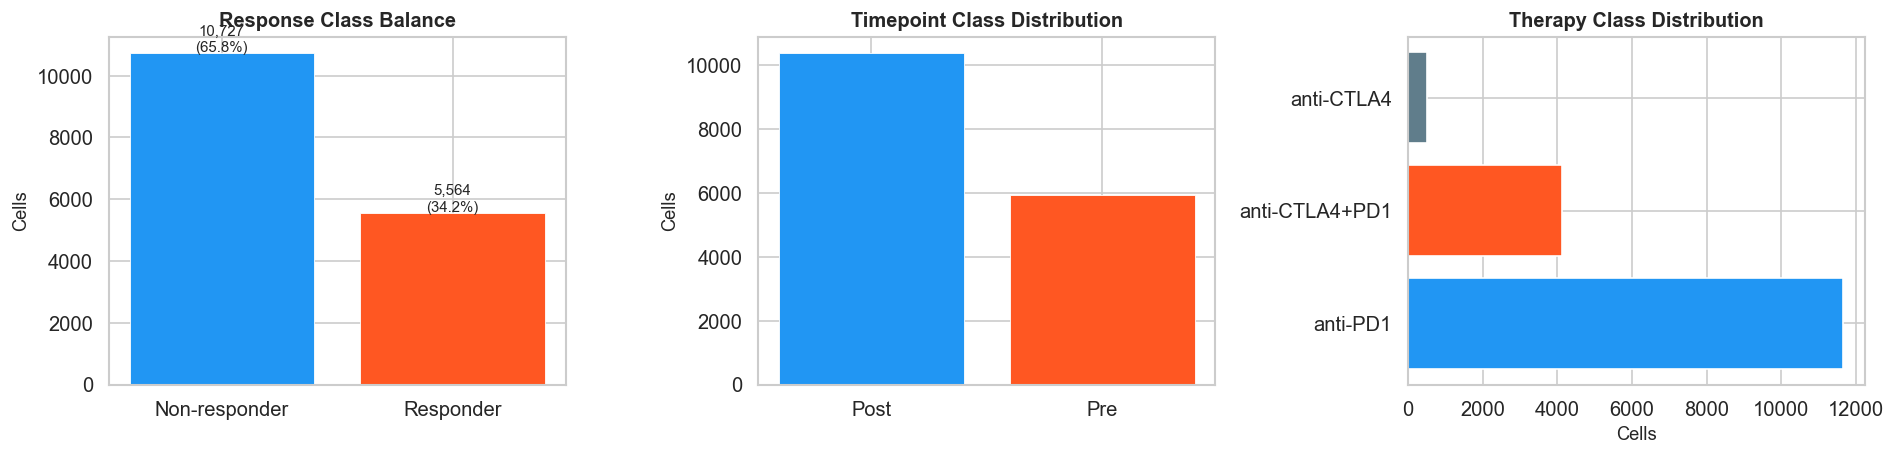

The class imbalance ratio NR:R is 1.93:1

The models will be trained 2x more on Non-responder cells than on Responders ones.


In [29]:
# Exploring the distribution of the main metadata variables in the filtered dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Response Class Distribution across cells
response_labels = {1: "Responder",0: "Non-responder"}
response_counts = (adata_filtered.obs["response"].map(response_labels).value_counts())
axes[0].bar(response_counts.index, response_counts.values,color=["#2196F3", "#FF5722"], edgecolor="white", linewidth=0.5)
axes[0].set_title("Response Class Balance", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Cells")
for i, (lbl, v) in enumerate(response_counts.items()):
    axes[0].text(i, v + 50, f"{v:,}\n({v/response_counts.sum()*100:.1f}%)", ha="center", fontsize=9)

# Patient Timepoint of Treatment (Pre / Post treatment)
timepoint_counts = adata_filtered.obs["timepoint"].value_counts()
axes[1].bar(timepoint_counts.index, timepoint_counts.values,color=["#2196F3", "#FF5722"], edgecolor="white", linewidth=0.5)
axes[1].set_title("Timepoint Class Distribution", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cells")


# Therapy Distribution Plot Panel
therapy_counts = adata_filtered.obs["therapy"].value_counts()
axes[2].barh(therapy_counts.index, therapy_counts.values,color=["#2196F3","#FF5722","#607D8B"], edgecolor="white")
axes[2].set_title("Therapy Class Distribution", fontsize=12, fontweight="bold")
axes[2].set_xlabel("Cells")



plt.tight_layout()
plt.savefig(figures_dir / "class_covariate_balances.png")
plt.show()


# Calculating Class Imbalance of Response Class
responder  = response_counts.get("Responder",0)
n_responder = response_counts.get("Non-responder",0)
print(f"The class imbalance ratio NR:R is {n_responder/responder:.2f}:1")
print("\nThe models will be trained 2x more on Non-responder cells than on Responders ones.")

---
# Normalisation & Log Transformation 

---

# HVGs

---

# Patient-Level Data Split

---

# References

> [1]. For notebook's presentation and visual amelioration: https://medium.com/@vihasharma1099a-complete-guide-to-beautify-your-jupyter-notebooks-d49e06fa8b3f  <br>
> [2]. Information regarding the Data of use for the Specific analysis: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSM3403554 <br>
> [3]. Sparse arrays (scipy.sparce): https://docs.scipy.org/doc/scipy/reference/sparse.html <br>
> [4]. save_npz files (scipy.sparce): https://docs.scipy.org/doc/scipy/reference/generated/scipy.sparse.save_npz.html <br>
> [5]. PRECISE-: https://github.com/yizhak-lab-ccg/PRECISE- <br>
> [6]. Guide to filtering and subsetting single-cell anndata and pandas objects | basic and advanced: https://youtu.be/68ZUcr1rSCU?si=ssQ7QksLZCvJIixj
> [7]. Python RegEx:https://www.w3schools.com/python/python_regex.asp <br>
 